In [1]:
from jqdata import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime
import warnings
from tqdm import tqdm
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch.utils.data import TensorDataset

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体设置-黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
today = str(datetime.datetime.today().date())

# 获取所有ETF，过滤流动性较差的

In [2]:
#获得etf基金列表
df = get_all_securities(['etf'])
df = df.reset_index().rename(columns={'index':'code'})
df = df[df['start_date'] < datetime.date(2023, 1, 1)]

In [3]:
# 剔除成交额过低（流动性差）的etf
codes = []
for code in df.code:
    price = get_price(code, end_date=today, count=1000).dropna()
    price['pchg'] = price['close'].pct_change()
    if price['money'].mean() > 5e7: # 日均低于5000w成交额
        codes.append([code, price['money'].mean()/1e8, price['pchg'].mean(), price['pchg'].std()])
    else:
        print(f"排除{code} {df[df['code']==code]['display_name'].iloc[0]}, 成交额均值 {round(price['money'].mean()/1e7, 2)}kw")
codes = pd.DataFrame(codes, columns=['code', 'money','pchg_mean','pchg_std'])
df = df.merge(codes, how='inner', on='code')

排除159003.XSHE 招商快线ETF, 成交额均值 2.92kw
排除159005.XSHE 汇添富快钱ETF, 成交额均值 0.51kw
排除159603.XSHE 双创龙头ETF, 成交额均值 0.77kw
排除159606.XSHE 中证500成长ETF, 成交额均值 1.2kw
排除159608.XSHE 稀有金属ETF, 成交额均值 1.72kw
排除159609.XSHE 光伏龙头ETF, 成交额均值 2.0kw
排除159610.XSHE 500ETF增强, 成交额均值 4.94kw
排除159612.XSHE 标普500ETF, 成交额均值 2.6kw
排除159613.XSHE 信息安全ETF, 成交额均值 0.84kw
排除159616.XSHE 农牧ETF, 成交额均值 0.44kw
排除159617.XSHE 500价值ETF, 成交额均值 0.42kw
排除159618.XSHE 光伏ETF指数基金, 成交额均值 1.14kw
排除159619.XSHE 基建ETF, 成交额均值 3.2kw
排除159620.XSHE 500成长ETF, 成交额均值 0.19kw
排除159621.XSHE MSCIESGETF, 成交额均值 0.54kw
排除159623.XSHE 成渝经济圈ETF, 成交额均值 0.83kw
排除159625.XSHE 绿色电力ETF, 成交额均值 3.56kw
排除159627.XSHE A100ETF, 成交额均值 0.33kw
排除159630.XSHE A100ETF基金, 成交额均值 0.84kw
排除159631.XSHE 中证A100ETF, 成交额均值 1.44kw
排除159635.XSHE 基建50ETF, 成交额均值 2.12kw
排除159637.XSHE 新能源车龙头ETF, 成交额均值 4.13kw
排除159639.XSHE 碳中和ETF南方, 成交额均值 2.45kw
排除159640.XSHE 碳中和龙头ETF, 成交额均值 1.45kw
排除159641.XSHE 双碳ETF, 成交额均值 1.6kw
排除159642.XSHE 碳中和100ETF, 成交额均值 0.77kw
排除159643.XSHE 疫苗ETF, 成交额均值 2.12kw
排除159645.XSHE 疫苗E

排除159978.XSHE 大湾区ETF, 成交额均值 0.07kw
排除159979.XSHE 湾创100ETF, 成交额均值 0.02kw
排除159981.XSHE 能源化工ETF, 成交额均值 2.36kw
排除159982.XSHE 中证500ETF鹏华, 成交额均值 1.33kw
排除159983.XSHE 粤港澳大湾区ETF, 成交额均值 0.24kw
排除159984.XSHE 湾区100ETF, 成交额均值 0.05kw
排除159986.XSHE 消费100ETF, 成交额均值 0.13kw
排除159987.XSHE 科技创新ETF, 成交额均值 0.42kw
排除159988.XSHE 粤债ETF, 成交额均值 0.03kw
排除159990.XSHE 小盘价值ETF, 成交额均值 0.28kw
排除159991.XSHE 创大盘ETF, 成交额均值 0.76kw
排除159998.XSHE 计算机ETF, 成交额均值 3.58kw
排除159999.XSHE 永赢中证500ETF, 成交额均值 0.19kw
排除510010.XSHG 治理ETF, 成交额均值 0.01kw
排除510020.XSHG 超大ETF, 成交额均值 0.19kw
排除510030.XSHG 价值ETF, 成交额均值 0.14kw
排除510060.XSHG 央企ETF, 成交额均值 0.16kw
排除510070.XSHG 民企ETF, 成交额均值 0.0kw
排除510090.XSHG ESG建信, 成交额均值 0.01kw
排除510110.XSHG 周期ETF, 成交额均值 0.03kw
排除510120.XSHG 非周ETF, 成交额均值 0.01kw
排除510130.XSHG 中盘ETF, 成交额均值 0.06kw
排除510150.XSHG 消费ETF, 成交额均值 2.92kw
排除510160.XSHG 产业升级, 成交额均值 0.08kw
排除510170.XSHG 商品ETF, 成交额均值 0.56kw
排除510190.XSHG 上证50基, 成交额均值 0.13kw
排除510200.XSHG 上证券商, 成交额均值 0.34kw
排除510220.XSHG 中小ETF, 成交额均值 0.02kw
排除510260.XSHG 新兴ETF

排除516570.XSHG 石化ETF, 成交额均值 0.78kw
排除516580.XSHG 新能源BS, 成交额均值 0.89kw
排除516590.XSHG 电动汽车, 成交额均值 1.72kw
排除516600.XSHG 消服ETF, 成交额均值 0.43kw
排除516610.XSHG 医服ETF, 成交额均值 0.77kw
排除516620.XSHG 影视ETF, 成交额均值 1.31kw
排除516630.XSHG 云计算50, 成交额均值 0.74kw
排除516640.XSHG 芯片龙头, 成交额均值 4.48kw
排除516650.XSHG 有色50, 成交额均值 0.4kw
排除516660.XSHG 新能汽车, 成交额均值 3.29kw
排除516670.XSHG 畜牧养殖, 成交额均值 2.63kw
排除516680.XSHG 有色金属, 成交额均值 0.34kw
排除516690.XSHG 化工产业, 成交额均值 0.29kw
排除516700.XSHG 数据产业, 成交额均值 0.31kw
排除516710.XSHG 新材料50, 成交额均值 0.42kw
排除516720.XSHG ESGETF, 成交额均值 1.08kw
排除516730.XSHG 证券公司, 成交额均值 1.46kw
排除516750.XSHG 建材ETF, 成交额均值 2.13kw
排除516760.XSHG 养殖ETF, 成交额均值 0.73kw
排除516770.XSHG 游戏动漫, 成交额均值 1.77kw
排除516790.XSHG 保健ETF, 成交额均值 0.67kw
排除516800.XSHG 智能制造ETF, 成交额均值 0.86kw
排除516810.XSHG 农业, 成交额均值 0.8kw
排除516820.XSHG 医疗创新, 成交额均值 3.06kw
排除516830.XSHG 300ESG, 成交额均值 0.9kw
排除516850.XSHG 新能源80, 成交额均值 0.51kw
排除516860.XSHG 金融科技, 成交额均值 1.08kw
排除516870.XSHG 汽车, 成交额均值 0.64kw
排除516890.XSHG 新材ETF, 成交额均值 0.4kw
排除516900.XSHG 食品50, 成交额均值 0.84kw

In [4]:
raw_codes = df.sort_values('pchg_std')

# 获取ETF日线数据

In [5]:
today = datetime.datetime.today().date()
end_date = str(today)  # 计算截止日

prices = []
for code in df.code:
    price = get_price(code, fields='close',end_date=end_date, count=240)
    price['pchg'] = price['close'].pct_change()
    prices.append(price['pchg'].values)
prices = np.array(prices).T
prices = pd.DataFrame(prices, columns=df.code).iloc[1:]

# K-Means对ETF走势进行聚类
## 为了避免误杀，我这里把聚类簇的数量设置的比较多，如果太少的话不相似的ETF也可能聚到一起

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
x = prices.T
n_clusters = 30
cluster = KMeans(n_clusters=n_clusters,random_state=42)
y_pred = cluster.fit_predict(x)   ## 每个样本所对应的簇的标签

print(silhouette_score(x, y_pred))

x['cluster_id'] = y_pred

0.4511880967361387


In [9]:
x = x.reset_index().rename(columns={'index':'code'})
df = df.merge(x[['code','cluster_id']]).sort_values(['cluster_id', 'start_date'])

# 聚类到同一个簇里的ETF，仅保留发行时间最早的，原因如下：
## 1. 成立最早的一般成交额最大，流动性最好
## 2. 成立最早的历史数据最多，做模型训练数据也更多

In [10]:
# 每个簇里面选 成立最早的
df = df.groupby('cluster_id').first()

# 然而聚类效果并不能一次解决问题，如下所示还是有部分类似的ETF被保留下来
# 当然了，这个池子也是能用的

In [11]:
df

,code,display_name,name,start_date,end_date,type,money,pchg_mean,pchg_std
cluster_id,,,,,,,,,
0,159915.XSHE,创业板ETF,CYB,2011-12-09,2200-01-01,etf,11.421485,-0.000397,0.015955
1,513050.XSHG,中概互联,ZGHL,2017-01-18,2200-01-01,etf,11.798626,-0.000377,0.019956
2,510050.XSHG,50ETF,50ETF,2005-02-23,2200-01-01,etf,20.239826,-0.000160,0.010893
3,511010.XSHG,国债ETF,GZETF,2013-03-25,2200-01-01,etf,2.537861,0.000124,0.001059
4,513060.XSHG,恒生医疗,HSYL,2021-03-29,2200-01-01,etf,7.842216,-0.001027,0.022175
5,515700.XSHG,新能车,XNC,2020-02-10,2200-01-01,etf,2.191583,0.000149,0.021606
6,513100.XSHG,纳指ETF,NZETF,2013-05-15,2200-01-01,etf,3.051073,0.000763,0.015046
7,512400.XSHG,有色ETF,YSJS,2017-09-01,2200-01-01,etf,2.011344,0.000350,0.020177
8,512720.XSHG,计算机,JSJ,2019-08-16,2200-01-01,etf,0.674596,-0.000554,0.017867


# 如果想要更精简的池子就继续上武器：相关系数过滤，ETF之间两两计算相关系数，当相关系数超过0.85（我拍的）的ETF对，仅保留成立时间早的

In [12]:
# 再用相关系数聚类一遍
corr = prices[df.code].corr()

codes = df.code.tolist()
union = []
for i in codes:
    for j in codes:
        if i == j:
            continue
        if corr.loc[i, j] > 0.85:
            find = False
            for k in range(len(union)):
                if i in union[k] or j in union[k]:
                    union[k].add(i)
                    union[k].add(j)
                    find = True
            if not find:
                union.append(set([i, j]))

In [13]:
# 同理，仅保留成立最早的
remove = []
for i in union:
    remove += df[df['code'].isin(i)].sort_values('start_date').iloc[1:]['code'].tolist()
print('corr 剔除: ', remove)
df = df[~df['code'].isin(remove)]

corr 剔除:  ['159922.XSHE', '512100.XSHG', '512480.XSHG', '515700.XSHG', '588000.XSHG', '513050.XSHG', '512100.XSHG', '512720.XSHG', '588000.XSHG']


# 看下结果是不是清爽很多

In [14]:
df

,code,display_name,name,start_date,end_date,type,money,pchg_mean,pchg_std
cluster_id,,,,,,,,,
0,159915.XSHE,创业板ETF,CYB,2011-12-09,2200-01-01,etf,11.421485,-0.000397,0.015955
2,510050.XSHG,50ETF,50ETF,2005-02-23,2200-01-01,etf,20.239826,-0.000160,0.010893
3,511010.XSHG,国债ETF,GZETF,2013-03-25,2200-01-01,etf,2.537861,0.000124,0.001059
4,513060.XSHG,恒生医疗,HSYL,2021-03-29,2200-01-01,etf,7.842216,-0.001027,0.022175
6,513100.XSHG,纳指ETF,NZETF,2013-05-15,2200-01-01,etf,3.051073,0.000763,0.015046
7,512400.XSHG,有色ETF,YSJS,2017-09-01,2200-01-01,etf,2.011344,0.000350,0.020177
11,512010.XSHG,医药ETF,YYETF,2013-10-28,2200-01-01,etf,4.074185,-0.000655,0.016815
12,512980.XSHG,传媒ETF,CMETF,2018-01-19,2200-01-01,etf,1.034101,-0.000376,0.019402
13,159920.XSHE,恒生ETF,HSETF,2012-10-22,2200-01-01,etf,8.025912,-0.000177,0.013606


# （可选）如果要构建ETF候选池用于模型训练的，过滤下数据较少的EFT，即把成立晚的ETF剔除，这里我拍的2020年为阈值

# 最终结果里是不是有很多是经常出现在ETF策略里的老熟人，也可以一定程度解释为啥要选这几只ETF组合做策略比较好

In [15]:
# 去掉较晚成立的
remove = df[df['start_date'] > datetime.date(2020, 1, 1)]['code'].tolist()
print('成立时间：剔除2020后成立的', remove)
df = df[~df['code'].isin(remove)]
df

成立时间：剔除2020后成立的 ['513060.XSHG', '513360.XSHG', '515790.XSHG', '516110.XSHG', '515210.XSHG', '159825.XSHE', '159647.XSHE']


,code,display_name,name,start_date,end_date,type,money,pchg_mean,pchg_std
cluster_id,,,,,,,,,
0,159915.XSHE,创业板ETF,CYB,2011-12-09,2200-01-01,etf,11.421485,-0.000397,0.015955
2,510050.XSHG,50ETF,50ETF,2005-02-23,2200-01-01,etf,20.239826,-0.000160,0.010893
3,511010.XSHG,国债ETF,GZETF,2013-03-25,2200-01-01,etf,2.537861,0.000124,0.001059
6,513100.XSHG,纳指ETF,NZETF,2013-05-15,2200-01-01,etf,3.051073,0.000763,0.015046
7,512400.XSHG,有色ETF,YSJS,2017-09-01,2200-01-01,etf,2.011344,0.000350,0.020177
11,512010.XSHG,医药ETF,YYETF,2013-10-28,2200-01-01,etf,4.074185,-0.000655,0.016815
12,512980.XSHG,传媒ETF,CMETF,2018-01-19,2200-01-01,etf,1.034101,-0.000376,0.019402
13,159920.XSHE,恒生ETF,HSETF,2012-10-22,2200-01-01,etf,8.025912,-0.000177,0.013606
14,512070.XSHG,证券保险,FYETF,2014-07-18,2200-01-01,etf,1.505260,-0.000268,0.015010


# 画一下走势图人眼看下是不是相关度比较低，还比较符合预期
## 注意，我的方法只是筛选相关度低，流动性好的ETF，所以结果中会有一些和其他相关低但是常年下跌的，比如医药ETF，房产ETF，我这里没把它从池子里剔除，你做策略回测可以把它剔除掉，不过这也算是引入了未来函数吧？
## 换句话说，如果你的池子里有常年下跌的，但是策略收益仍然可观，那是不是说明策略鲁棒性较好，你也说不准以前一直下跌的ETF未来会不会反转大涨吧？

100%|██████████| 16/16 [00:01<00:00, 15.86it/s]


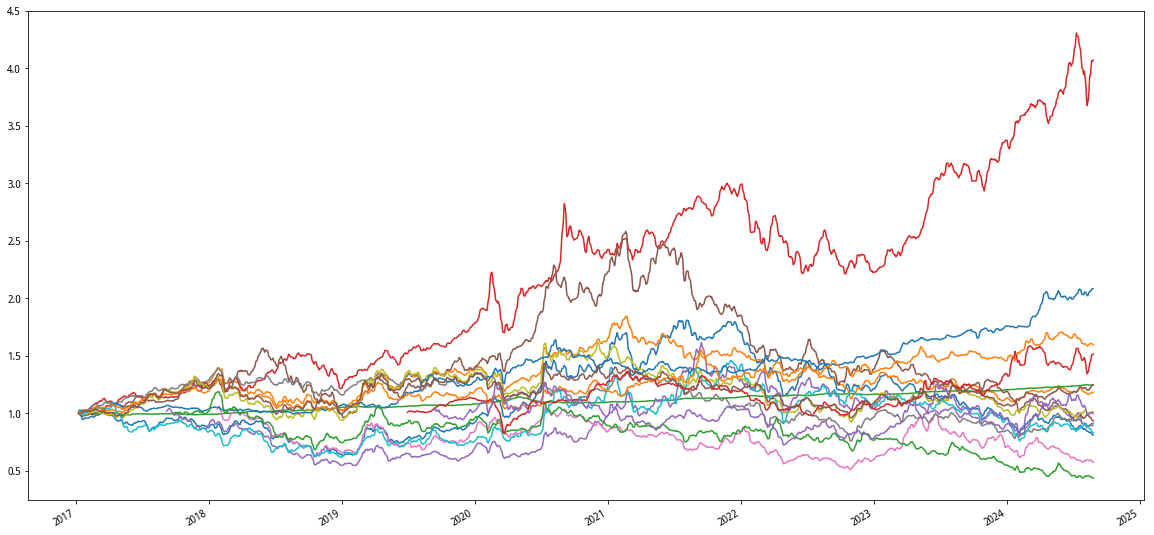

In [16]:
plt.rcParams['figure.figsize'] = [20, 10]
codes = df.code.unique().tolist()
df = []
for code in tqdm(codes):
    tmp = get_price(code, start_date='2017-01-01', end_date=today, fields=['close', 'low']).dropna()
    tmp['close_norm'] = tmp['close'] / tmp['close'].iloc[0]
    tmp['close_norm'] = tmp['close_norm'].rolling(5).mean()
    tmp['close_norm'].plot()
    tmp['code'] = code
    df.append(tmp)
df = pd.concat(df).dropna()

# 一个Tip：如果要用于模型训练，511010 国债ETF要去掉
## 1. 国债ETF基本和余额宝一样，走势几乎是一个直线，稳定收益没有波动，和其他波动较大的ETF相比完全是异常值，会严重干扰模型学习，起码我测试是这样
## 2. 而且国债ETF的收益/走势还需要预测么？